# Taller - Rasterización desde Cero: Dibujando con Algoritmos Clásicos

**Estudiante:** Grupo 5  
**Fecha de entrega:** 9 de marzo, 2026

## 📋 Descripción y Objetivos

Este taller implementa los **algoritmos clásicos de rasterización** para primitivas gráficas fundamentales, construyendo imágenes píxel a píxel **sin librerías de alto nivel** de dibujo.

### Objetivos
- Implementar el **Algoritmo de Bresenham** para rasterización eficiente de líneas
- Implementar el **Algoritmo de Punto Medio** para dibujar círculos
- Implementar la **Rasterización Scanline** para rellenar triángulos
- Comparar precisión, eficiencia conceptual y uso de cada método

### Herramientas utilizadas
- `Pillow` — creación y modificación directa de píxeles
- `NumPy` — soporte para operaciones matriciales
- `Matplotlib` — visualización de resultados

In [9]:
import os
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

# Ensure the media output directory exists
MEDIA_DIR = os.path.join('..', 'media')
os.makedirs(MEDIA_DIR, exist_ok=True)

print("✓ Libraries loaded. Media directory ready:", os.path.abspath(MEDIA_DIR))

✓ Libraries loaded. Media directory ready: d:\INGENIERIA DE SISTEMAS Y COMPUTACION\Semestre VIII\CompuacionVisualGrupo5\semana_3_1_algoritmos_rasterizacion_basica\media


## 1. Entorno de Dibujo

Se crea un canvas en blanco usando `PIL.Image`. Cada algoritmo escribe directamente sobre el arreglo de píxeles via `pixels[x, y] = (R, G, B)`.  
El uso de un canvas de **400×400** permite apreciar mejor los detalles de cada primitiva.

In [10]:
# --- Canvas dimensions ---
WIDTH, HEIGHT = 400, 400

def create_canvas(w=WIDTH, h=HEIGHT, bg='white'):
    """Create a blank RGB canvas and return (image, pixel_accessor)."""
    img = Image.new('RGB', (w, h), bg)
    return img, img.load()

# Verify the helper works correctly
img_test, px_test = create_canvas()
print(f"✓ Canvas helper ready — default size: {WIDTH}×{HEIGHT} pixels")

✓ Canvas helper ready — default size: 400×400 pixels


## 2. Algoritmo de Bresenham — Rasterización de Líneas

### Fundamento Teórico

El **Algoritmo de Bresenham** (Jack Elton Bresenham, 1965) traza líneas usando exclusivamente **aritmética entera**, eliminando costosas operaciones de punto flotante.

**Idea principal:**
- Define `dx = |x₁ - x₀|` y `dy = |y₁ - y₀|`
- Mantiene un error acumulado `err = dx - dy`
- En cada iteración, decide si avanzar en X, en Y, o en ambas direcciones:
  - Si `2·err > -dy` → avanza en X
  - Si `2·err < dx`  → avanza en Y

**Complejidad:** O(max(dx, dy)) — un paso por píxel a lo largo del eje dominante.  
**Ventaja clave:** Solo sumas y restas de enteros → óptimo para hardware gráfico.

✓ Guardado: ..\media\bresenham_lines.png


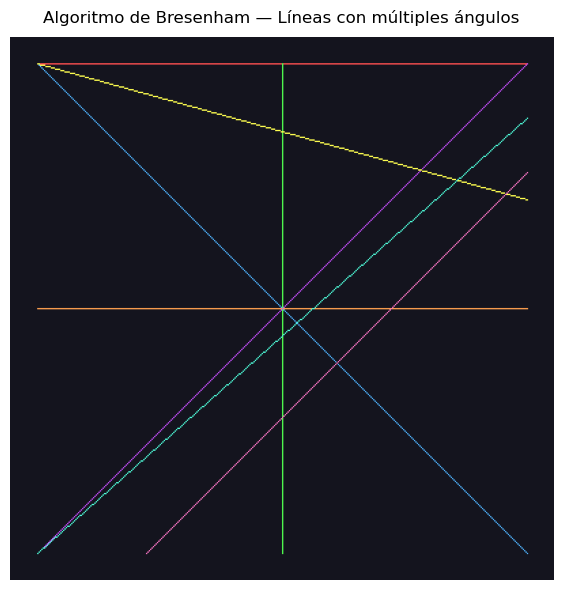

In [11]:
def bresenham(pixels, x0, y0, x1, y1, color=(255, 0, 0)):
    """
    Algoritmo de Bresenham para rasterización de líneas.
    Traza una línea de (x0, y0) a (x1, y1) usando solo aritmética entera.

    Args:
        pixels     : Accessor de píxeles de PIL Image
        x0, y0     : Punto inicial
        x1, y1     : Punto final
        color      : Color RGB como tupla (R, G, B)
    """
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1   # Dirección de avance en X
    sy = 1 if y0 < y1 else -1   # Dirección de avance en Y
    err = dx - dy                # Error acumulado inicial

    while True:
        # Pintar el píxel actual si está dentro del canvas
        if 0 <= x0 < WIDTH and 0 <= y0 < HEIGHT:
            pixels[x0, y0] = color

        if x0 == x1 and y0 == y1:
            break           # Se alcanzó el punto final

        e2 = 2 * err
        if e2 > -dy:        # Componente horizontal
            err -= dy
            x0 += sx
        if e2 < dx:         # Componente vertical
            err += dx
            y0 += sy


# --- Demostración: líneas con diferentes pendientes y ángulos ---
img_bresen, px_bresen = create_canvas(bg=(20, 20, 30))   # Canvas oscuro

test_lines = [
    (20,  20,  380, 20,   (255, 80,  80)),    # Horizontal superior    (rojo)
    (20,  200, 380, 200,  (255, 160, 80)),    # Horizontal central     (naranja)
    (200, 20,  200, 380,  (80,  255, 80)),    # Vertical               (verde)
    (20,  20,  380, 380,  (80,  180, 255)),   # Diagonal 45° ↘         (azul)
    (380, 20,  20,  380,  (200, 80,  255)),   # Diagonal 45° ↙         (morado)
    (20,  20,  380, 120,  (255, 255, 80)),    # Pendiente baja ~15°    (amarillo)
    (20,  380, 380, 60,   (80,  255, 220)),   # Pendiente pronunciada  (cian)
    (100, 380, 380, 100,  (255, 120, 200)),   # Asimétrica              (rosa)
]

for x0, y0, x1, y1, col in test_lines:
    bresenham(px_bresen, x0, y0, x1, y1, col)

# Guardar en media/
save_path = os.path.join(MEDIA_DIR, 'bresenham_lines.png')
img_bresen.save(save_path)
print(f"✓ Guardado: {save_path}")

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(img_bresen)
plt.title('Algoritmo de Bresenham — Líneas con múltiples ángulos', fontsize=12, pad=10)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'bresenham_display.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Algoritmo de Punto Medio — Rasterización de Círculos

### Fundamento Teórico

El **Algoritmo de Punto Medio** (variante del algoritmo de Bresenham para círculos) explota la **simetría de 8 octantes** del círculo para calcular solo 1/8 de los puntos.

**Idea principal:**
- Parte en `(r, 0)` y avanza incrementando `y`
- Mantiene un parámetro de decisión `p = 1 - r`
  - Si `p ≤ 0`: el punto medio está **dentro** del círculo → solo incrementa Y
  - Si `p > 0`: el punto medio está **fuera** → decrementa X también

**Simetría de 8 octantes:** cada punto `(x, y)` calculado genera 8 puntos:  
`(±x, ±y)` y `(±y, ±x)`

**Complejidad:** O(r) — ~r/√2 iteraciones con aritmética entera.

✓ Guardado: ..\media\midpoint_circles.png


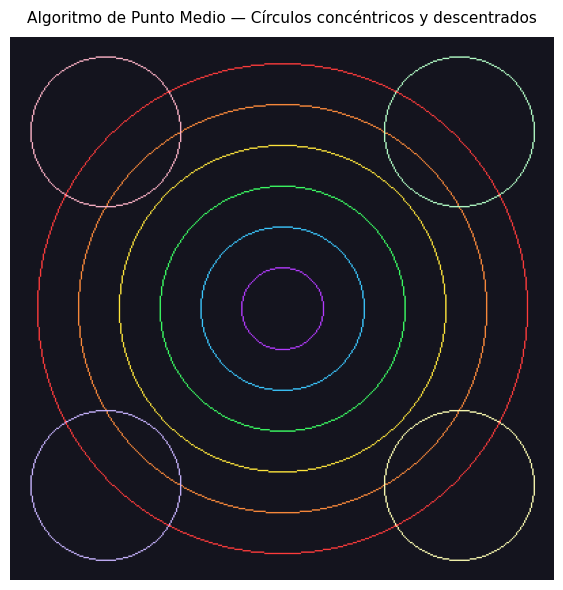

In [12]:
def midpoint_circle(pixels, x0, y0, radius, color=(0, 100, 255)):
    """
    Algoritmo de Punto Medio para rasterización de círculos.
    Usa la simetría de 8 octantes para dibujar el círculo completo
    calculando solo el primer octante.

    Args:
        pixels     : Accessor de píxeles de PIL Image
        x0, y0     : Centro del círculo
        radius     : Radio en píxeles
        color      : Color RGB como tupla (R, G, B)
    """
    x = radius
    y = 0
    p = 1 - radius     # Parámetro de decisión inicial

    while x >= y:
        # Reflejar el punto calculado en los 8 octantes simétricos
        for dx, dy in [(x, y), (y, x), (-x, y), (-y, x),
                       (-x, -y), (-y, -x), (x, -y), (y, -x)]:
            px, py = x0 + dx, y0 + dy
            if 0 <= px < WIDTH and 0 <= py < HEIGHT:
                pixels[px, py] = color

        y += 1
        if p <= 0:
            p = p + 2 * y + 1             # Avanzar solo en Y
        else:
            x -= 1
            p = p + 2 * y - 2 * x + 1    # Avanzar en Y, decrementar X


# --- Demostración: círculos concéntricos y descentrados ---
img_circle, px_circle = create_canvas(bg=(20, 20, 30))

cx, cy = WIDTH // 2, HEIGHT // 2

# Anillos concéntricos con gradiente de colores
concentric = [
    (180, (255, 60,   60)),
    (150, (255, 140,  60)),
    (120, (255, 230,  60)),
    (90,  (60,  255, 100)),
    (60,  (60,  200, 255)),
    (30,  (180, 60,  255)),
]
for r, col in concentric:
    midpoint_circle(px_circle, cx, cy, r, col)

# Círculos adicionales en las esquinas
midpoint_circle(px_circle, 70,  70,  55, (255, 180, 200))
midpoint_circle(px_circle, 330, 70,  55, (180, 255, 200))
midpoint_circle(px_circle, 70,  330, 55, (200, 180, 255))
midpoint_circle(px_circle, 330, 330, 55, (255, 255, 180))

# Guardar en media/
save_path = os.path.join(MEDIA_DIR, 'midpoint_circles.png')
img_circle.save(save_path)
print(f"✓ Guardado: {save_path}")

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(img_circle)
plt.title('Algoritmo de Punto Medio — Círculos concéntricos y descentrados', fontsize=11, pad=10)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'circles_display.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Rasterización Scanline — Rellenado de Triángulos

### Fundamento Teórico

La **Rasterización Scanline** rellena triángulos barriendo el interior fila a fila (*scan line* = línea horizontal de píxeles).

**Pasos del algoritmo:**
1. Ordenar los 3 vértices de mayor a menor Y (de arriba hacia abajo)
2. Para cada fila `y` dentro del triángulo, calcular la **intersección X** con los dos bordes activos mediante interpolación lineal
3. Pintar todos los píxeles entre `x_izquierdo` y `x_derecho`

**Interpolación lineal de bordes:**

$$x(y) = x_0 + (x_1 - x_0) \cdot \frac{y - y_0}{y_1 - y_0}$$

**Complejidad:** O(área) — rellena cada píxel del interior exactamente una vez.  
**Base de las GPUs modernas:** toda la rasterización de triángulos en tiempo real sigue esta idea.

✓ Guardado: ..\media\scanline_triangles.png


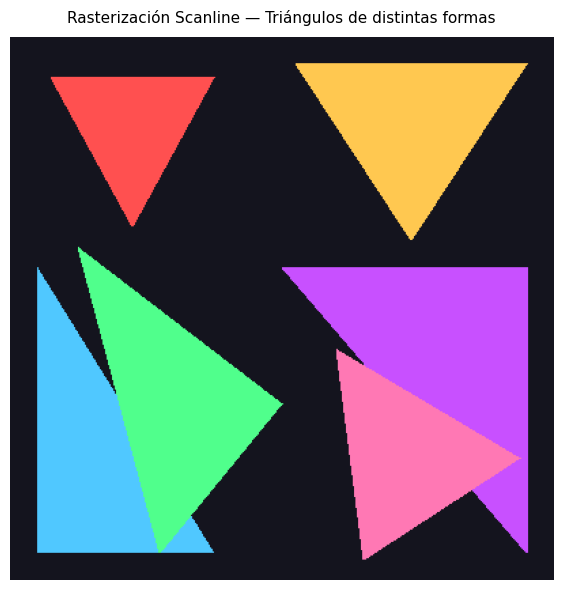

In [13]:
def fill_triangle(pixels, p1, p2, p3, color=(0, 200, 80)):
    """
    Rasterización por Scanline para triángulos rellenos.
    Recorre el triángulo fila a fila (scanline), interpolando
    los bordes izquierdo y derecho para cada línea horizontal.

    Args:
        pixels      : Accessor de píxeles de PIL Image
        p1, p2, p3  : Vértices del triángulo como tuplas (x, y)
        color       : Color RGB de relleno como tupla (R, G, B)
    """
    # 1. Ordenar vértices de arriba a abajo por coordenada Y
    pts = sorted([p1, p2, p3], key=lambda p: p[1])
    (x1, y1), (x2, y2), (x3, y3) = pts

    def interpolate(ya, yb, xa, xb):
        """Interpola los valores X para filas entre ya (inclusive) e yb (exclusive)."""
        if yb == ya:
            return []
        return [int(xa + (xb - xa) * (y - ya) / (yb - ya)) for y in range(ya, yb)]

    # 2. Calcular los tres bordes del triángulo
    x12 = interpolate(y1, y2, x1, x2)   # Segmento superior  (y1 → y2)
    x23 = interpolate(y2, y3, x2, x3)   # Segmento inferior  (y2 → y3)
    x13 = interpolate(y1, y3, x1, x3)   # Borde largo total  (y1 → y3)

    x_combined = x12 + x23   # Borde corto combinado (lado opuesto al largo)

    # 3. Pintar cada scanline entre el borde largo y el combinado
    for y, xl, xr in zip(range(y1, y3), x13, x_combined):
        for x in range(min(xl, xr), max(xl, xr) + 1):
            if 0 <= x < WIDTH and 0 <= y < HEIGHT:
                pixels[x, y] = color


# --- Demostración: triángulos de distintas formas ---
img_tri, px_tri = create_canvas(bg=(20, 20, 30))

triangles = [
    # (p1,           p2,           p3,           color)
    ((30,  30),  (150, 30),  (90,  140), (255, 80,  80)),    # Isósceles
    ((210, 20),  (380, 20),  (295, 150), (255, 200, 80)),    # Equilátero aprox.
    ((20,  170), (150, 380), (20,  380), (80,  200, 255)),   # Rectángulo
    ((200, 170), (380, 170), (380, 380), (200, 80,  255)),   # Rectángulo invertido
    ((50,  155), (200, 270), (110, 380), (80,  255, 140)),   # Escaleno
    ((240, 230), (375, 310), (260, 385), (255, 120, 180)),   # Agudo estrecho
]

for p1, p2, p3, col in triangles:
    fill_triangle(px_tri, p1, p2, p3, col)

# Guardar en media/
save_path = os.path.join(MEDIA_DIR, 'scanline_triangles.png')
img_tri.save(save_path)
print(f"✓ Guardado: {save_path}")

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(img_tri)
plt.title('Rasterización Scanline — Triángulos de distintas formas', fontsize=11, pad=10)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'triangles_display.png'), dpi=150, bbox_inches='tight')
plt.show()

✓ Imagen combinada guardada: ..\media\combined_rasterization.png


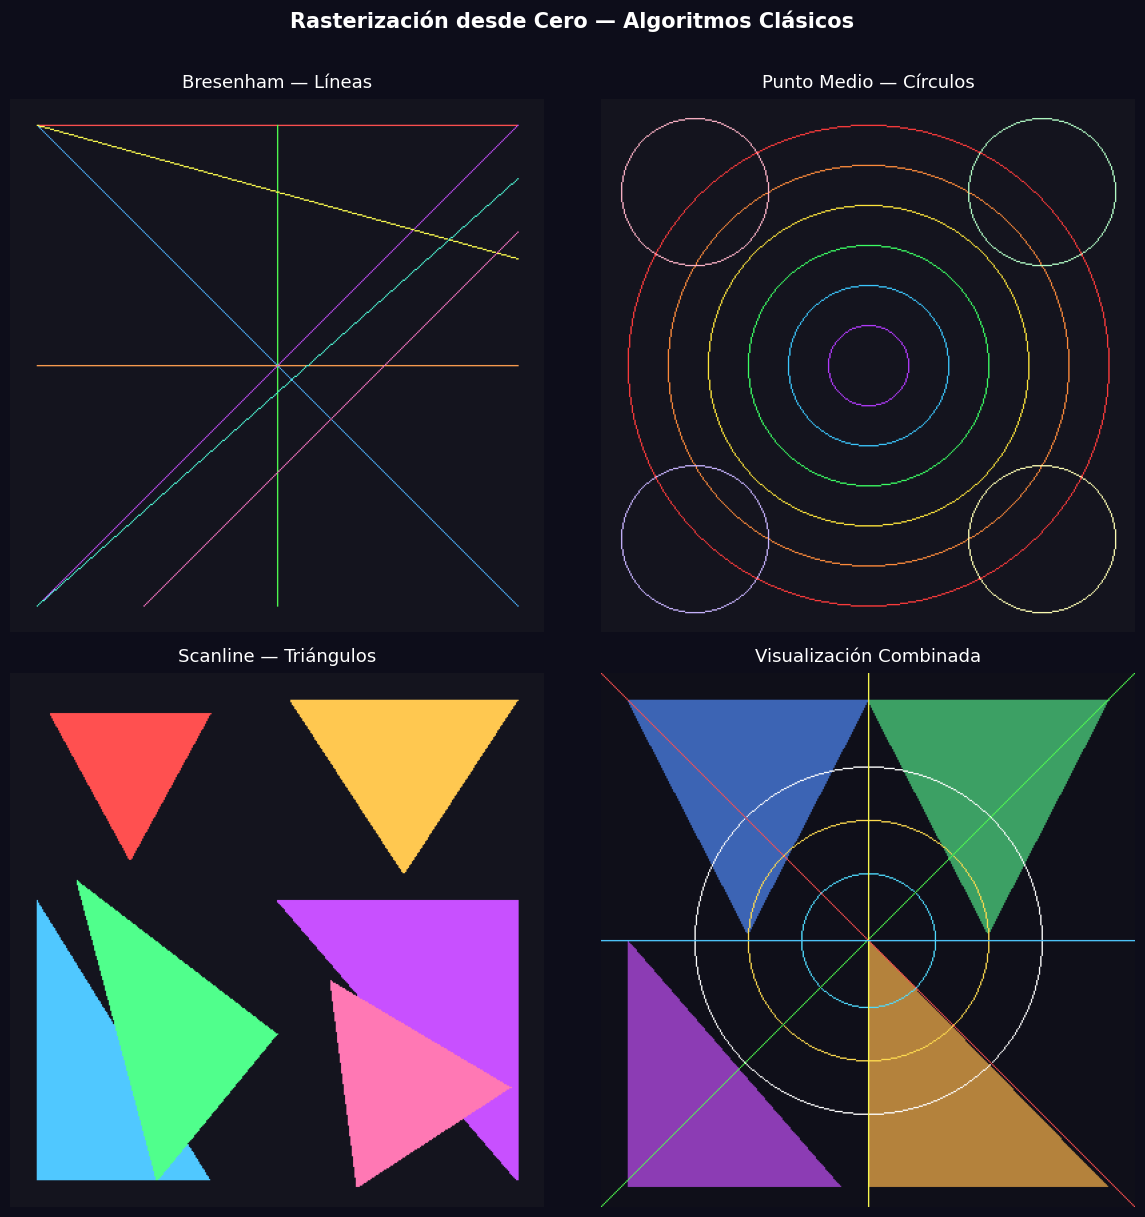

✓ Grid completo guardado.


In [14]:
# --- Visualización combinada: todas las primitivas en un único canvas ---
img_combined, px_combined = create_canvas(bg=(15, 15, 25))

# Triángulos de fondo
fill_triangle(px_combined, (20,  20),  (200, 20),  (110, 195), (60,  100, 180))
fill_triangle(px_combined, (200, 20),  (380, 20),  (290, 195), (60,  160, 100))
fill_triangle(px_combined, (20,  200), (180, 385), (20,  385), (140, 60,  180))
fill_triangle(px_combined, (200, 200), (380, 385), (200, 385), (180, 130, 60))

# Círculos concéntricos al centro
midpoint_circle(px_combined, 200, 200, 130, (255, 255, 255))
midpoint_circle(px_combined, 200, 200, 90,  (255, 220, 80))
midpoint_circle(px_combined, 200, 200, 50,  (80,  220, 255))

# Líneas de Bresenham superpuestas
bresenham(px_combined, 0,   0,   399, 399, (255, 80,  80))
bresenham(px_combined, 399, 0,   0,   399, (80,  255, 80))
bresenham(px_combined, 200, 0,   200, 399, (255, 255, 80))
bresenham(px_combined, 0,   200, 399, 200, (80,  200, 255))

# Guardar imagen combinada
save_path = os.path.join(MEDIA_DIR, 'combined_rasterization.png')
img_combined.save(save_path)
print(f"✓ Imagen combinada guardada: {save_path}")

# --- Grid comparativo: los 4 resultados ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.patch.set_facecolor('#0d0d1a')

plot_data = [
    (img_bresen,   'Bresenham — Líneas'),
    (img_circle,   'Punto Medio — Círculos'),
    (img_tri,      'Scanline — Triángulos'),
    (img_combined, 'Visualización Combinada'),
]

for ax, (img, title) in zip(axes.flat, plot_data):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=13, pad=8)
    ax.axis('off')

plt.suptitle('Rasterización desde Cero — Algoritmos Clásicos',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'all_algorithms_grid.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✓ Grid completo guardado.")

## 5. Reflexión y Análisis Comparativo

### Comparación entre los algoritmos

| Algoritmo    | Primitiva  | Aritmética        | Complejidad      | Uso típico                       |
|:-------------|:----------:|:-----------------:|:-----------------|:---------------------------------|
| Bresenham    | Línea      | Solo enteros      | O(max(dx, dy))   | Bordes, wireframes, rejillas     |
| Punto Medio  | Círculo    | Solo enteros      | O(r)             | UI, curvas, efectos circulares   |
| Scanline     | Triángulo  | Enteros + div     | O(área)          | Relleno de polígonos en GPU/CPU  |

### ¿Cuál es más rápido?
- **Bresenham** es el más eficiente por paso: una suma y una resta de enteros por píxel.
- **Punto Medio** aprovecha la simetría ×8, calculando solo ~r/√2 puntos reales.
- **Scanline** es el más costoso en total (proporcional al área del triángulo), pero es **indispensable** para superficies rellenas.

### ¿Cuál es más preciso?
- **Bresenham** y **Punto Medio** tienen precisión de ±1 píxel en el borde de la forma.
- **Scanline** puede tener pequeños artefactos en vértices horizontales (`dy = 0`), manejados con el caso especial en `interpolate`.

### Aprendizajes
1. Toda imagen digital es una grilla de píxeles — la eficiencia de estos algoritmos fue crítica en la era del hardware lento.
2. La idea del "error acumulado" de Bresenham convierte una decisión continua en discreta de forma elegante.
3. La simetría de 8 octantes del círculo reduce el trabajo 8 veces — un principio de optimización que se repite en gráficos.
4. El algoritmo scanline es la base de la rasterización de triángulos en GPUs modernas.